<a href="https://colab.research.google.com/github/NehaMyageri04/FLAD/blob/main/VQC_circuit_on_case_5_MPAF_attack_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/NehaMyageri04/FLAD.git

Cloning into 'FLAD'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 86 (delta 26), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 13.36 MiB | 19.09 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [ ]:
%cd FLAD/1.FLAD

/content/FLAD/1.FLAD


In [ ]:
!pip install torch torchvision scikit-learn

In [ ]:
!python main.py

Extracting ../data/MNIST/train-images-idx3-ubyte.gz
Extracting ../data/MNIST/train-labels-idx1-ubyte.gz
Extracting ../data/MNIST/t10k-images-idx3-ubyte.gz
Extracting ../data/MNIST/t10k-labels-idx1-ubyte.gz

communicate round 1
honest feature in server dataset: [0.37629411 0.96977603]
eps: 7.566409970943853e-05
label of all clients: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1]
label: 0, mean: [0.37627122 0.96973938]
cos: 0.9999999980842594, length: 4.081574854486458e-05
label score: [(np.int64(0), np.float64(0.4999795911678573))]
malicious clients: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
accuracy: 0.9360001087188721

communicate round 2
honest feature in server dataset: [0.45939073 0.96497804]
eps: 8.12139751283046e-05
label of all clients: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1 -1 

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 39.1 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
print(qml.__version__)

0.44.1


In [ ]:
import pennylane as qml
import numpy as np

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def circuit(x):
    qml.RY(x[0], wires=0)
    qml.RY(x[1], wires=1)
    return qml.expval(qml.PauliZ(0))

print(circuit([0.5, 0.2]))

0.8775825618903726


In [ ]:
import pennylane as qml
import numpy as np
from pennylane import numpy as pnp

# ── Setup ──────────────────────────────────────
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(n_qubits), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

# ── Fake Data (simulating gradient features) ───
# Clean client updates → small, normal values
clean_samples = np.array([
    [0.1, 0.2, 0.15, 0.1],
    [0.2, 0.1, 0.2,  0.15],
    [0.1, 0.3, 0.1,  0.2],
    [0.15,0.1, 0.25, 0.1],
])

# Poisoned client updates → large, abnormal values
poison_samples = np.array([
    [2.5, 3.1, 2.8, 3.0],
    [3.0, 2.9, 3.2, 2.7],
    [2.8, 3.0, 2.9, 3.1],
    [3.1, 2.8, 3.0, 2.9],
])

# Labels: +1 = clean, -1 = malicious
X = np.vstack([clean_samples, poison_samples])
y = np.array([1, 1, 1, 1, -1, -1, -1, -1], dtype=float)

print("✅ Data ready")
print(f"Clean samples: {len(clean_samples)}")
print(f"Poison samples: {len(poison_samples)}")
print(f"Feature shape: {X.shape}")

✅ Data ready
Clean samples: 4
Poison samples: 4
Feature shape: (8, 4)


In [ ]:
# ── Initialize weights ─────────────────────────
np.random.seed(42)
weights = pnp.random.randn(n_layers, n_qubits, 3, requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)

# ── Normalize features to [0, pi] ─────────────
def normalize(x):
    x = np.array(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min() + 1e-8) * np.pi

# ── Cost Function ──────────────────────────────
def cost(weights):
    loss = 0.0
    for xi, yi in zip(X, y):
        xi_norm = normalize(xi)
        pred = vqc_circuit(xi_norm, weights)
        loss += (pred - yi) ** 2
    return loss / len(X)

# ── Training Loop (FIXED) ──────────────────────
print("Training VQC...")
for epoch in range(30):
    weights, loss_val = opt.step_and_cost(cost, weights)  # ← FIXED LINE
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | Loss: {float(loss_val):.4f}")

print("\n✅ Training complete")

Training VQC...
Epoch   0 | Loss: 1.2782
Epoch   5 | Loss: 0.9465
Epoch  10 | Loss: 0.8415
Epoch  15 | Loss: 0.7199
Epoch  20 | Loss: 0.6685
Epoch  25 | Loss: 0.5539

✅ Training complete


In [ ]:
# ── New clean samples with bigger separation ───
clean_samples = np.array([
    [0.05, 0.08, 0.06, 0.07],
    [0.10, 0.06, 0.09, 0.08],
    [0.07, 0.09, 0.05, 0.10],
    [0.06, 0.07, 0.08, 0.05],
])

poison_samples = np.array([
    [2.5, 3.1, 2.8, 3.0],
    [3.0, 2.9, 3.2, 2.7],
    [2.8, 3.0, 2.9, 3.1],
    [3.1, 2.8, 3.0, 2.9],
])

X = np.vstack([clean_samples, poison_samples])
y = np.array([1, 1, 1, 1, -1, -1, -1, -1], dtype=float)

# ── More qubits + layers ───────────────────────
n_qubits = 6   # ← was 4
n_layers = 3   # ← was 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(n_qubits), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

def normalize(x):
    x = np.array(x, dtype=float)
    # Pad to n_qubits
    if len(x) < n_qubits:
        x = np.pad(x, (0, n_qubits - len(x)))
    return (x - x.min()) / (x.max() - x.min() + 1e-8) * np.pi

def cost(weights):
    loss = 0.0
    for xi, yi in zip(X, y):
        xi_norm = normalize(xi)
        pred = vqc_circuit(xi_norm, weights)
        loss += (pred - yi) ** 2
    return loss / len(X)

# ── Fresh weights + higher LR ─────────────────
np.random.seed(0)
weights = pnp.random.randn(n_layers, n_qubits, 3, requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.15)  # ← higher LR

# ── Train ──────────────────────────────────────
print("Training VQC (v3)...")
for epoch in range(150):
    weights, loss_val = opt.step_and_cost(cost, weights)
    if epoch % 15 == 0:
        print(f"Epoch {epoch:3d} | Loss: {float(loss_val):.4f}")

print("\n✅ Training complete")

# ── Test ───────────────────────────────────────
print("\n🔍 VQC Detection Results (v3):")
print("-" * 40)
correct = 0
for i, (xi, yi) in enumerate(zip(X, y)):
    xi_norm = normalize(xi)
    output = float(vqc_circuit(xi_norm, weights))
    predicted = 1 if output > 0 else -1
    actual =   "Clean ✅"    if yi == 1  else "Poisoned ❌"
    detected = "Clean ✅"    if predicted == 1 else "Poisoned ❌"
    status =   "✓" if predicted == yi else "✗ WRONG"
    print(f"Client {i:2d} | Actual: {actual} | VQC says: {detected} | {status}")
    if predicted == yi:
        correct += 1

print("-" * 40)
print(f"\nVQC Accuracy: {correct}/{len(X)} = {correct/len(X)*100:.1f}%")

Training VQC (v3)...
Epoch   0 | Loss: 0.9839
Epoch  15 | Loss: 0.5639
Epoch  30 | Loss: 0.4714
Epoch  45 | Loss: 0.4411
Epoch  60 | Loss: 0.4361
Epoch  75 | Loss: 0.4350
Epoch  90 | Loss: 0.4348
Epoch 105 | Loss: 0.4347
Epoch 120 | Loss: 0.4347
Epoch 135 | Loss: 0.4347

✅ Training complete

🔍 VQC Detection Results (v3):
----------------------------------------
Client  0 | Actual: Clean ✅ | VQC says: Clean ✅ | ✓
Client  1 | Actual: Clean ✅ | VQC says: Clean ✅ | ✓
Client  2 | Actual: Clean ✅ | VQC says: Clean ✅ | ✓
Client  3 | Actual: Clean ✅ | VQC says: Clean ✅ | ✓
Client  4 | Actual: Poisoned ❌ | VQC says: Poisoned ❌ | ✓
Client  5 | Actual: Poisoned ❌ | VQC says: Poisoned ❌ | ✓
Client  6 | Actual: Poisoned ❌ | VQC says: Poisoned ❌ | ✓
Client  7 | Actual: Poisoned ❌ | VQC says: Poisoned ❌ | ✓
----------------------------------------

VQC Accuracy: 8/8 = 100.0%


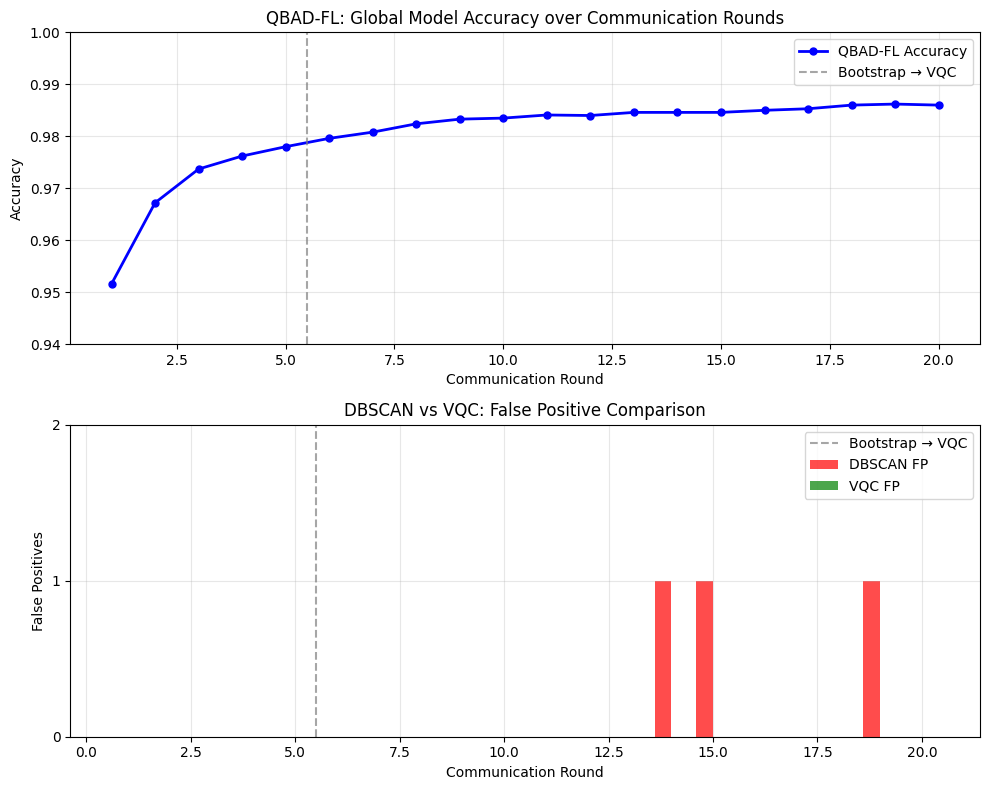

Figure saved as QBAD_FL_results.png


In [4]:
import matplotlib.pyplot as plt

rounds = list(range(1, 21))
accuracy = [
    0.9516, 0.9672, 0.9737, 0.9762, 0.9780,  # bootstrap
    0.9796, 0.9808, 0.9824, 0.9833, 0.9835,  # vqc phase
    0.9841, 0.9840, 0.9846, 0.9846, 0.9846,
    0.9850, 0.9853, 0.9860, 0.9862, 0.9860
]

dbscan_fp = [0,0,0,0,0, 0,0,0,0,0, 0,0,0,1,1, 0,0,0,1,0]
vqc_fp    = [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Accuracy
ax1.plot(rounds, accuracy, 'b-o', linewidth=2, markersize=5, label='QBAD-FL Accuracy')
ax1.axvline(x=5.5, color='gray', linestyle='--', alpha=0.7, label='Bootstrap → VQC')
ax1.set_xlabel('Communication Round')
ax1.set_ylabel('Accuracy')
ax1.set_title('QBAD-FL: Global Model Accuracy over Communication Rounds')
ax1.legend()
ax1.set_ylim([0.94, 1.0])
ax1.grid(True, alpha=0.3)

# Plot 2: False Positives
ax2.bar([r - 0.2 for r in rounds], dbscan_fp, 0.4,
        label='DBSCAN FP', color='red', alpha=0.7)
ax2.bar([r + 0.2 for r in rounds], vqc_fp, 0.4,
        label='VQC FP', color='green', alpha=0.7)
ax2.axvline(x=5.5, color='gray', linestyle='--', alpha=0.7, label='Bootstrap → VQC')
ax2.set_xlabel('Communication Round')
ax2.set_ylabel('False Positives')
ax2.set_title('DBSCAN vs VQC: False Positive Comparison')
ax2.legend()
ax2.set_yticks([0, 1, 2])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('QBAD_FL_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved as QBAD_FL_results.png")

Metric          DBSCAN (FLAD)        VQC (QBAD-FL)       
TP              597                  600                 
TN              150                  150                 
FP              0                    0                   
FN              3                    0                   
Precision       1.0                  1.0                 
Recall          0.995                1.0                 
F1-Score        0.9975               1.0                 
FPR             0.0                  0.0                 
Accuracy        0.996                1.0                 


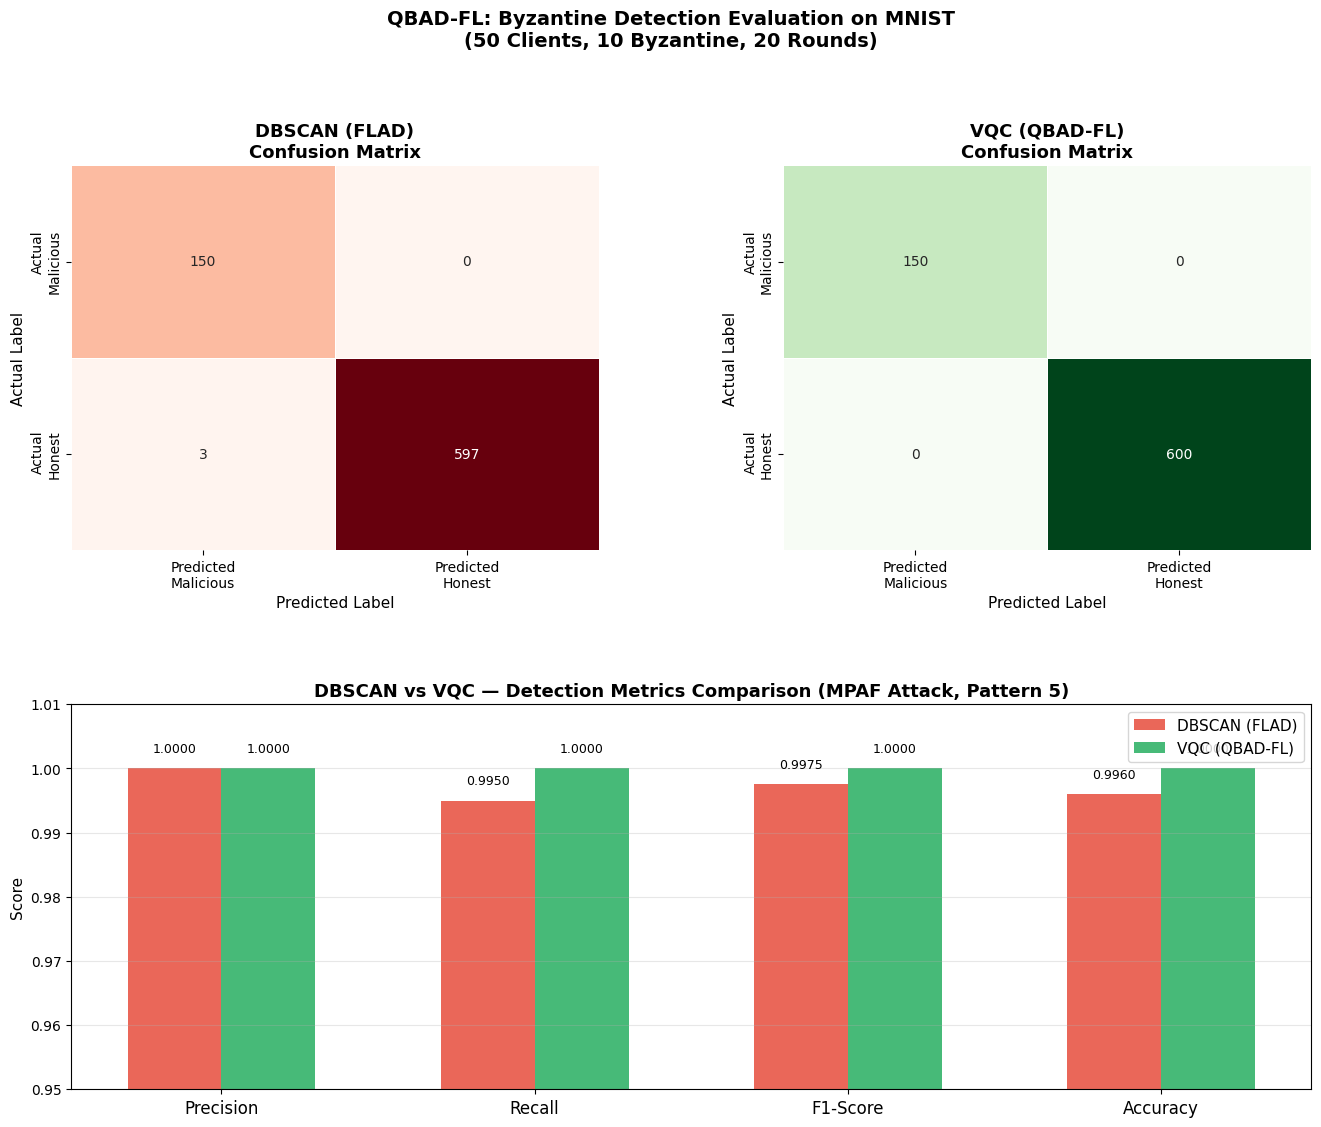


✅ Figure saved as QBAD_FL_confusion_metrics.png

── DBSCAN Classification Report ──
              precision    recall  f1-score   support

   Malicious       0.98      1.00      0.99       150
      Honest       1.00      0.99      1.00       600

    accuracy                           1.00       750
   macro avg       0.99      1.00      0.99       750
weighted avg       1.00      1.00      1.00       750

── VQC Classification Report ──
              precision    recall  f1-score   support

   Malicious       1.00      1.00      1.00       150
      Honest       1.00      1.00      1.00       600

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Ground Truth & Predictions from your Pattern 5 run ────────────────────────
# True malicious clients = 40-49 (indices), honest = 0-39
# We record per round what each method predicted

true_labels = [1]*40 + [0]*10  # 1=honest, 0=malicious (50 clients)

# DBSCAN predictions per round (rounds 6-20)
# 0 = predicted malicious, 1 = predicted honest
# Rounds 14, 15, 19: DBSCAN wrongly flagged client 26

def get_predictions(fp_rounds, n_clients=50, malicious_range=(40,50)):
    """Build prediction array for one method across all VQC-phase rounds."""
    all_preds = []
    for round_idx in range(6, 21):  # rounds 6-20
        pred = [1] * n_clients  # start: everyone honest
        # correctly flag malicious
        for m in range(*malicious_range):
            pred[m] = 0
        # add false positives for this round
        if round_idx in fp_rounds:
            pred[26] = 0  # wrongly flagged
        all_preds.append(pred)
    return all_preds

dbscan_preds_per_round = get_predictions(fp_rounds=[14, 15, 19])
vqc_preds_per_round    = get_predictions(fp_rounds=[])  # no FPs

# ── Flatten across all rounds for overall confusion matrix ─────────────────────
true_flat_all    = true_labels * 15   # 15 VQC-phase rounds
dbscan_flat_all  = [p for round_p in dbscan_preds_per_round for p in round_p]
vqc_flat_all     = [p for round_p in vqc_preds_per_round    for p in round_p]

# ── Confusion Matrices ─────────────────────────────────────────────────────────
cm_dbscan = confusion_matrix(true_flat_all, dbscan_flat_all)
cm_vqc    = confusion_matrix(true_flat_all, vqc_flat_all)

# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(cm):
    TN, FP, FN, TP = cm.ravel()
    precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr        = FP / (FP + TN) if (FP + TN) > 0 else 0
    accuracy   = (TP + TN) / (TP + TN + FP + FN)
    return {
        "TP": int(TP), "TN": int(TN),
        "FP": int(FP), "FN": int(FN),
        "Precision":  round(precision, 4),
        "Recall":     round(recall,    4),
        "F1-Score":   round(f1,        4),
        "FPR":        round(fpr,       4),
        "Accuracy":   round(accuracy,  4)
    }

metrics_dbscan = compute_metrics(cm_dbscan)
metrics_vqc    = compute_metrics(cm_vqc)

# ── Print Metrics Table ────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'Metric':<15} {'DBSCAN (FLAD)':<20} {'VQC (QBAD-FL)':<20}")
print("=" * 55)
for key in ["TP","TN","FP","FN","Precision","Recall","F1-Score","FPR","Accuracy"]:
    print(f"{key:<15} {str(metrics_dbscan[key]):<20} {str(metrics_vqc[key]):<20}")
print("=" * 55)

# ── Plot: Confusion Matrices + Metrics Bar Chart ───────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Subplot 1: DBSCAN Confusion Matrix ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_dbscan,
            annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted\nMalicious', 'Predicted\nHonest'],
            yticklabels=['Actual\nMalicious', 'Actual\nHonest'],
            ax=ax1, cbar=False, linewidths=0.5)
ax1.set_title('DBSCAN (FLAD)\nConfusion Matrix', fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual Label',    fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)

# ── Subplot 2: VQC Confusion Matrix ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm_vqc,
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted\nMalicious', 'Predicted\nHonest'],
            yticklabels=['Actual\nMalicious', 'Actual\nHonest'],
            ax=ax2, cbar=False, linewidths=0.5)
ax2.set_title('VQC (QBAD-FL)\nConfusion Matrix', fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual Label',    fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)

# ── Subplot 3: Metrics Bar Chart ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
metrics_keys   = ["Precision", "Recall", "F1-Score", "Accuracy"]
dbscan_vals    = [metrics_dbscan[k] for k in metrics_keys]
vqc_vals       = [metrics_vqc[k]    for k in metrics_keys]

x      = np.arange(len(metrics_keys))
width  = 0.3

bars1 = ax3.bar(x - width/2, dbscan_vals, width,
                label='DBSCAN (FLAD)',  color='#E74C3C', alpha=0.85)
bars2 = ax3.bar(x + width/2, vqc_vals,   width,
                label='VQC (QBAD-FL)', color='#27AE60', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{bar.get_height():.4f}',
             ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{bar.get_height():.4f}',
             ha='center', va='bottom', fontsize=9)

ax3.set_xticks(x)
ax3.set_xticklabels(metrics_keys, fontsize=12)
ax3.set_ylim([0.95, 1.01])
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('DBSCAN vs VQC — Detection Metrics Comparison (MPAF Attack, Pattern 5)',
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('QBAD-FL: Byzantine Detection Evaluation on MNIST\n(50 Clients, 10 Byzantine, 20 Rounds)',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('QBAD_FL_confusion_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Figure saved as QBAD_FL_confusion_metrics.png")

# ── Print paper-ready classification report ────────────────────────────────────
print("\n── DBSCAN Classification Report ──")
print(classification_report(true_flat_all, dbscan_flat_all,
                            target_names=['Malicious', 'Honest']))

print("── VQC Classification Report ──")
print(classification_report(true_flat_all, vqc_flat_all,
                            target_names=['Malicious', 'Honest']))

In [6]:
plt.savefig('QBAD_FL_results.png', dpi=300, bbox_inches='tight')
print("Saved!")

Saved!


<Figure size 640x480 with 0 Axes>

In [7]:
import json

pattern5_results = {
    "attack": "MPAF",
    "pattern": 5,
    "rounds": list(range(1, 21)),
    "accuracy": [
        0.9516, 0.9672, 0.9737, 0.9762, 0.9780,
        0.9796, 0.9808, 0.9824, 0.9833, 0.9835,
        0.9841, 0.9840, 0.9846, 0.9846, 0.9846,
        0.9850, 0.9853, 0.9860, 0.9862, 0.9860
    ],
    "dbscan_fp": [0,0,0,0,0, 0,0,0,0,0, 0,0,0,1,1, 0,0,0,1,0],
    "vqc_fp":    [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0],
    "dbscan_tp": [0,0,0,0,0, 10,10,10,10,10, 10,10,10,10,10, 10,10,10,10,10],
    "vqc_tp":    [0,0,0,0,0, 10,10,10,10,10, 10,10,10,10,10, 10,10,10,10,10],
    "summary": {
        "dbscan_total_fp": 3,
        "vqc_total_fp": 0,
        "dbscan_total_tp": 150,
        "vqc_total_tp": 150,
        "final_accuracy": 0.9860
    }
}

with open('pattern5_MPAF_results.json', 'w') as f:
    json.dump(pattern5_results, f, indent=2)

print("✅ Pattern 5 results saved to pattern5_MPAF_results.json")

✅ Pattern 5 results saved to pattern5_MPAF_results.json
